In [1]:
import numpy as np
from matplotlib import pyplot as plt

import sklearn
import urllib.request
from sklearn.decomposition import PCA

import pandas as pd
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures


In [110]:
from astroML.datasets import generate_mu_z
z_sample, mu_sample, dmu = generate_mu_z(500, random_state=1234) # YOU CANNOT CHANGE THIS

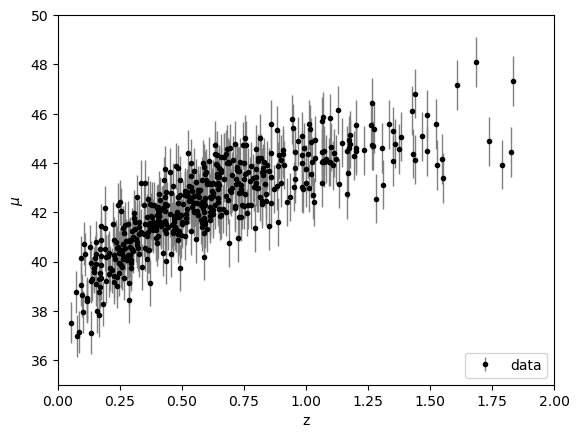

In [111]:
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50);

In [112]:
X = z_sample[:, np.newaxis]
y = mu_sample

In [113]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X, y, sample_weight=dmu)

theta0 = lin_reg.intercept_
theta1 = lin_reg.coef_

print('Parameters from LinearRegression: q = %.2f, m = %.2f' % (theta0, theta1))

X_new = np.array([[min(z_sample)],[max(z_sample)]])
y_pred = theta0+theta1*X_new


Parameters from LinearRegression: q = 39.87, m = 4.04


/tmp/ipykernel_29300/3675041915.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print('Parameters from LinearRegression: q = %.2f, m = %.2f' % (theta0, theta1))


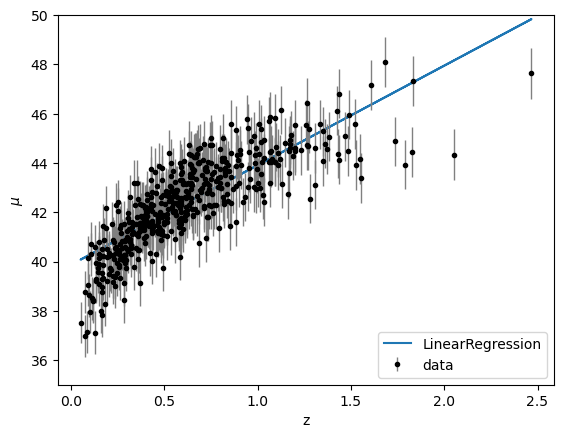

In [114]:
plt.plot(X[:,0],theta0+theta1*X[:,0],label='LinearRegression')
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
#plt.xlim(0,2)
plt.ylim(35,50);

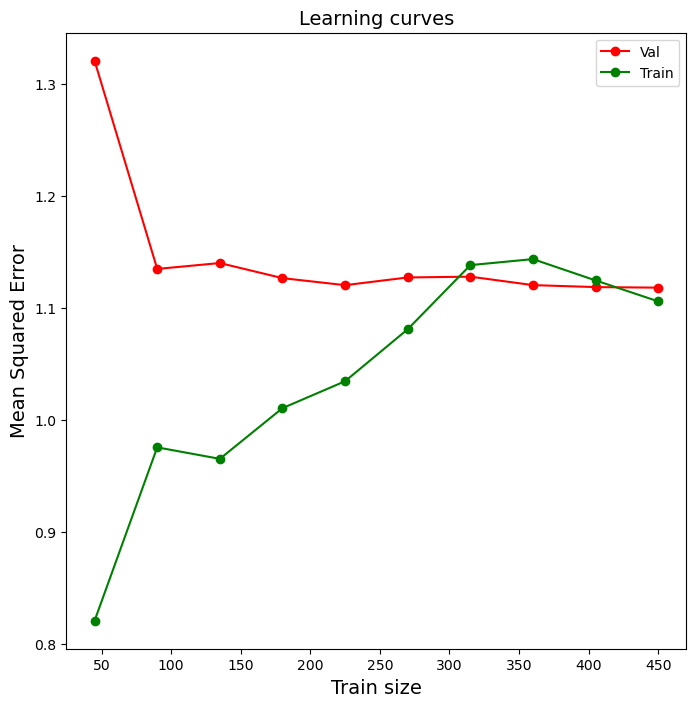

In [115]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import learning_curve


scaler = StandardScaler()
Xscaled = scaler.fit_transform(X)

lin_reg = LinearRegression()
# Ten training sample sizes from 10% to 100%
train_sizes, train_scores_linreg, test_scores_linreg = \
    learning_curve(lin_reg, Xscaled, y, train_sizes=np.linspace(0.1, 1, 10), \
    scoring="neg_mean_squared_error", cv=10)

fig = plt.figure(figsize=(8, 8))

plt.plot(train_sizes, -test_scores_linreg.mean(1), 'o-', color="r", label="Val")
plt.plot(train_sizes, -train_scores_linreg.mean(1), 'o-', color="g", label="Train")
                   
plt.xlabel("Train size",fontsize=14)
plt.ylabel("Mean Squared Error",fontsize=14)
plt.title('Learning curves',fontsize=14)
plt.legend(loc="best");
#plt.ylim(0,200)

#plt.show()

Parameters from PolynomialRegression with d = 5: [ 37.18628889  18.1688347  -24.65638106  20.96512538  -9.08856244
   1.50373045]


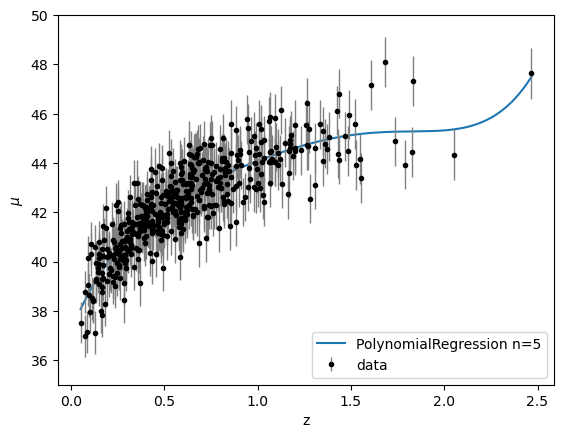

In [116]:
from astroML.linear_model import PolynomialRegression


degree = 5
model = PolynomialRegression(degree) # fit 3rd degree polynomial
model.fit(X, y,y_error=dmu)

y_pred = model.predict(X)
n_constraints = degree + 1

theta = (model.coef_)
print('Parameters from PolynomialRegression with d = ' + str(degree) + ': ' + str(theta))

X_test = np.linspace(min(z_sample),max(z_sample),1000)[:, np.newaxis]
y_pred = model.predict(X_test)

plt.plot(X_test[:,0],y_pred,label='PolynomialRegression n='+str(degree))
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
#plt.xlim(0,2)
plt.ylim(35,50);

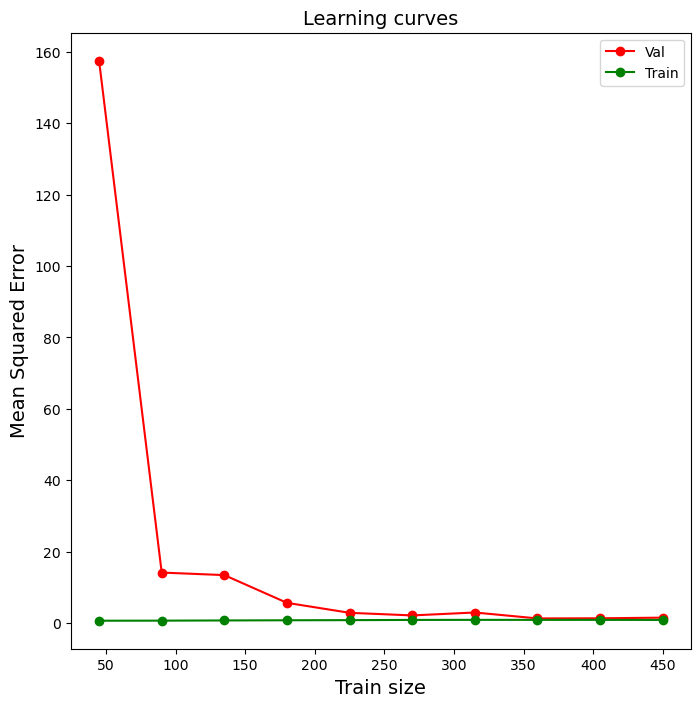

In [117]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import learning_curve


scaler = StandardScaler()
Xscaled = scaler.fit_transform(X)

# Ten training sample sizes from 10% to 100%
train_sizes, train_scores_linreg, test_scores_linreg = \
    learning_curve(model, Xscaled, y, train_sizes=np.linspace(0.1, 1, 10), \
    scoring="neg_mean_squared_error", cv=10)

fig = plt.figure(figsize=(8, 8))

plt.plot(train_sizes, -test_scores_linreg.mean(1), 'o-', color="r", label="Val")
plt.plot(train_sizes, -train_scores_linreg.mean(1), 'o-', color="g", label="Train")
                   
plt.xlabel("Train size",fontsize=14)
plt.ylabel("Mean Squared Error",fontsize=14)
plt.title('Learning curves',fontsize=14)
plt.legend(loc="best");
#plt.ylim(0,200)

#plt.show()

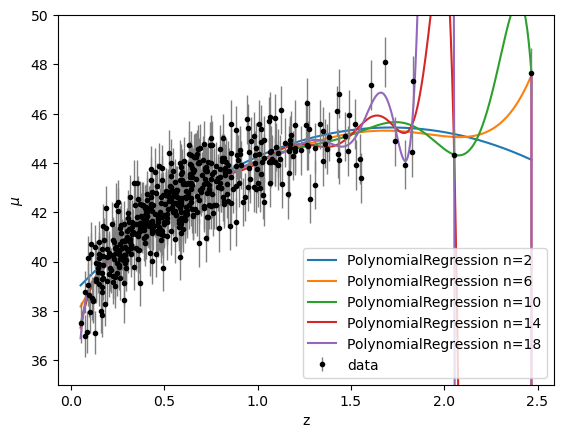

In [118]:
for n in np.arange(1,20)[1::4]:

    regressor = PolynomialRegression(n)
    regressor.fit(X, mu_sample, dmu)
    mu_fit = regressor.predict(X_test)
    plt.plot(X_test[:,0], mu_fit,label='PolynomialRegression n='+str(n))

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.ylim(35,50);

Parameters from BasisFunctionRegression with gaussians: [23.82931547  6.86684285  2.66148423  6.84885923  3.81098351  6.88326671
  4.69547266  5.92491486  7.94641572 -0.27084993 15.04437877]


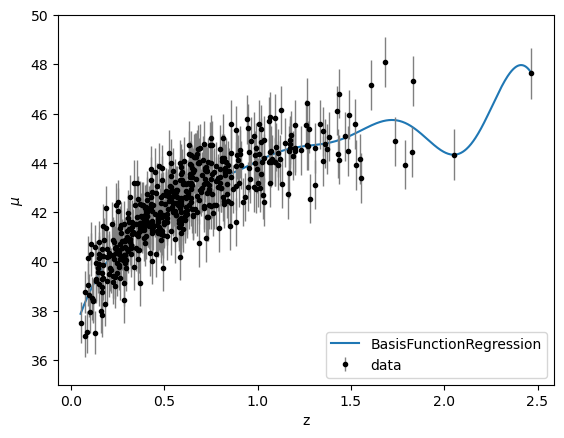

In [137]:
from astroML.linear_model import BasisFunctionRegression

# data

# mean positions of the 10 Gaussians in the model
X_gridtest = np.linspace(min(z_sample),max(z_sample),10)[:, None]
# widths of these Gaussians
sigma_test = (X_gridtest[1] - X_gridtest[0])

model = BasisFunctionRegression('gaussian', mu=X_gridtest, sigma=sigma_test)
model.fit(X, y, dmu)

y_pred = model.predict(X_test)
theta = (model.coef_)
print('Parameters from BasisFunctionRegression with gaussians: ' + str(theta))



plt.plot(X_test[:,0],y_pred,label='BasisFunctionRegression')
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.ylim(35,50);

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import learning_curve

#boston = load_boston()


scaler = StandardScaler()
Xscaled = scaler.fit_transform(X)

# Questo non funziona perché non prende i parametri di mu e sigma dati al modello :(
# Ten training sample sizes from 10% to 100%
# train_sizes, train_scores_linreg, test_scores_linreg = \
#     learning_curve(model, Xscaled, y, train_sizes=np.linspace(0.1, 1, 10), \
#     scoring="neg_mean_squared_error", cv=10)

# fig = plt.figure(figsize=(8, 8))

# plt.plot(train_sizes, -test_scores_linreg.mean(1), 'o-', color="r", label="Val")
# plt.plot(train_sizes, -train_scores_linreg.mean(1), 'o-', color="g", label="Train")
                   
# plt.xlabel("Train size",fontsize=14)
# plt.ylabel("Mean Squared Error",fontsize=14)
# plt.title('Learning curves',fontsize=14)
# plt.legend(loc="best");


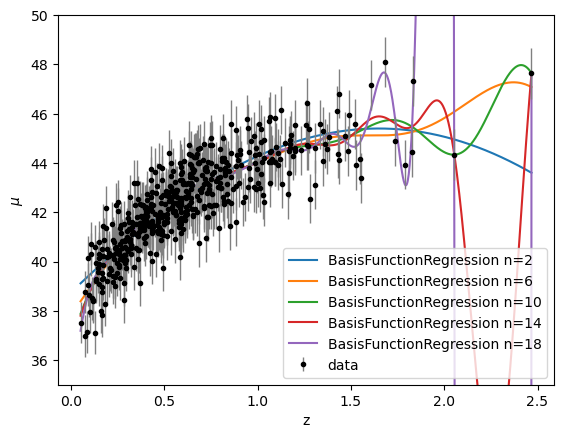

In [120]:
for n in np.arange(1,20)[1::4]:

    X_gridtest = np.linspace(min(z_sample),max(z_sample),n)[:, None]
    sigma_test = 1.0 * (X_gridtest[1] - X_gridtest[0])
    regressor = BasisFunctionRegression('gaussian', mu=X_gridtest, sigma=sigma_test)
    regressor.fit(X, mu_sample, dmu)
    mu_fit = regressor.predict(X_test)
    plt.plot(X_test[:,0], mu_fit,label='BasisFunctionRegression n='+str(n))

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.ylim(35,50);

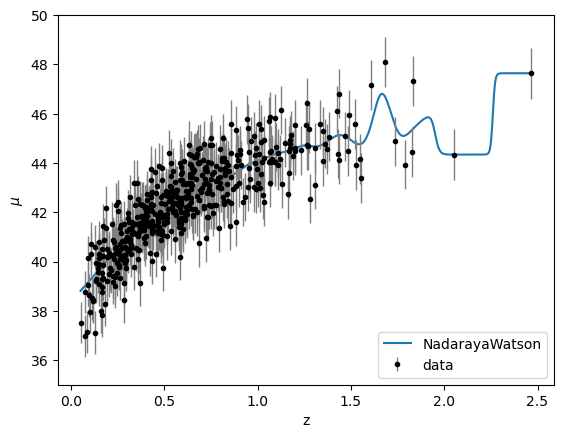

In [121]:
from astroML.linear_model import NadarayaWatson

model = NadarayaWatson(kernel='gaussian', h=0.05)
model.fit(X,y)

y_pred = model.predict(X_test)

plt.plot(X_test[:,0],y_pred,label='NadarayaWatson')
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.ylim(35,50);

/home/elisa/miniconda3/envs/fermipy/lib/python3.9/site-packages/astroML/linear_model/kernel_regression.py:52: RuntimeWarning: invalid value encountered in divide
  return (K * self.y).sum(1) / K.sum(1)
/home/elisa/miniconda3/envs/fermipy/lib/python3.9/site-packages/sklearn/model_selection/_validation.py:960: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/home/elisa/miniconda3/envs/fermipy/lib/python3.9/site-packages/sklearn/model_selection/_validation.py", line 949, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "/home/elisa/miniconda3/envs/fermipy/lib/python3.9/site-packages/sklearn/metrics/_scorer.py", line 288, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
  File "/home/elisa/miniconda3/envs/fermipy/lib/python3.9/site-packages/sklearn/metrics/_scorer.py", line 388, in _score
    return 

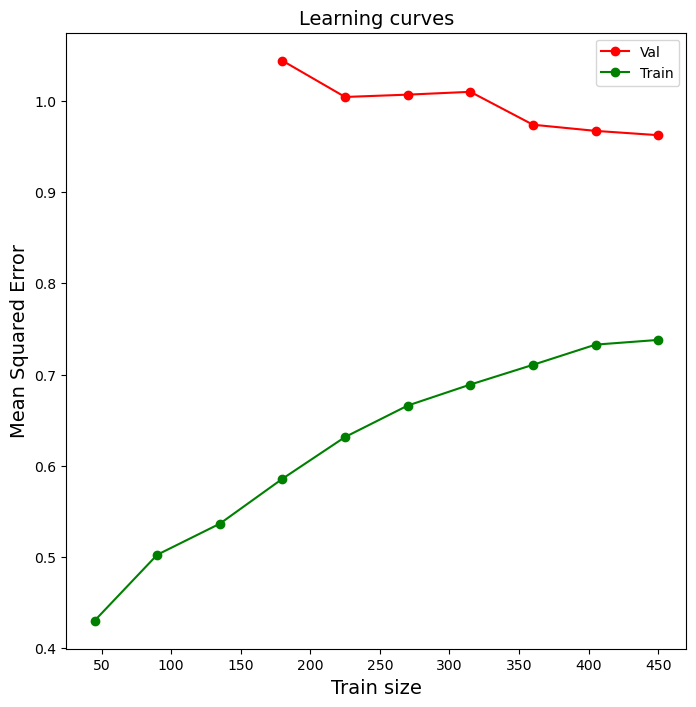

In [122]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import learning_curve


scaler = StandardScaler()
Xscaled = scaler.fit_transform(X)

# Ten training sample sizes from 10% to 100%
train_sizes, train_scores_linreg, test_scores_linreg = \
    learning_curve(model, Xscaled, y, train_sizes=np.linspace(0.1, 1, 10), \
    scoring="neg_mean_squared_error", cv=10)

fig = plt.figure(figsize=(8, 8))

plt.plot(train_sizes, -test_scores_linreg.mean(1), 'o-', color="r", label="Val")
plt.plot(train_sizes, -train_scores_linreg.mean(1), 'o-', color="g", label="Train")
                   
plt.xlabel("Train size",fontsize=14)
plt.ylabel("Mean Squared Error",fontsize=14)
plt.title('Learning curves',fontsize=14)
plt.legend(loc="best");
#plt.ylim(0,200)

#plt.show()

In [123]:
dy = dmu

Cross Validation on n in PolynomialRegression
-

In [124]:
from sklearn.model_selection import train_test_split

In [125]:
X_train, X_validation, ydy_train, ydy_validation = train_test_split(X, np.array([y,dy]).T, test_size=0.3, random_state=42)
y_train,dy_train = ydy_train.T
y_validation,dy_validation = ydy_validation.T

In [126]:
def geterror(X,y,classifier):
    return np.sqrt( np.sum(( y - classifier.predict(X) )**2) / len(X) )

def fitanderror(classifier):
    classifier.fit(X_train, y_train,dy_train)
    error_train = geterror(X_train,y_train,classifier)
    error_validation  = geterror(X_validation, y_validation, classifier)
    return error_train, error_validation

Polynomial Regression n= 1 1.0439541999509903 1.0770451545334463
Polynomial Regression n= 2 0.9224145458470545 1.0433457225165614
Polynomial Regression n= 3 0.903830523707167 0.9921071059083134
Polynomial Regression n= 4 0.9006469764028389 1.088063354632464
Polynomial Regression n= 5 0.8987325506276443 1.6229205033967586
Polynomial Regression n= 6 0.8987329631584619 1.4039237054269902
Polynomial Regression n= 7 0.8987367027959626 1.6528794588595976
Polynomial Regression n= 8 0.8976042305278417 46.54368723658712
Polynomial Regression n= 9 0.8971545090438204 33.493223811151246
Polynomial Regression n= 10 0.8956035443382131 512.6024016451014
Polynomial Regression n= 11 0.8930503041781427 2431.4727767993672
Polynomial Regression n= 12 0.8884846211235102 9798.141736518137
Polynomial Regression n= 13 0.8791437202793587 43919.430591687946
Polynomial Regression n= 14 0.8690349894003163 165165.3828140121
Polynomial Regression n= 15 0.8653115460836222 458264.6431339063
Polynomial Regression n= 1

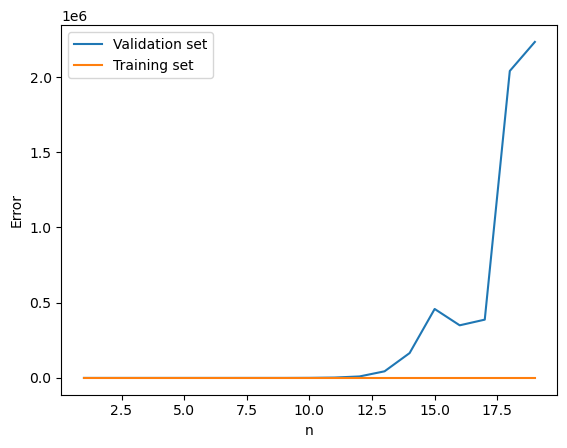

In [127]:
nrange = np.arange(1,20)

etrain, etest= [], []
for n in nrange:
    classifier = PolynomialRegression(n)
    error_train, error_validation = fitanderror(classifier)
    print("Polynomial Regression n=",n, error_train, error_validation)
    etrain.append(error_train)
    etest.append(error_validation)

plt.plot(nrange,etest, label='Validation set')
plt.plot(nrange,etrain, label='Training set')

plt.xlabel('n')
plt.ylabel('Error')
plt.legend()

print("Best", nrange[np.argmin(etest)], min(etest))

[37.9303641  11.53882123 -6.88381329  1.53889894]


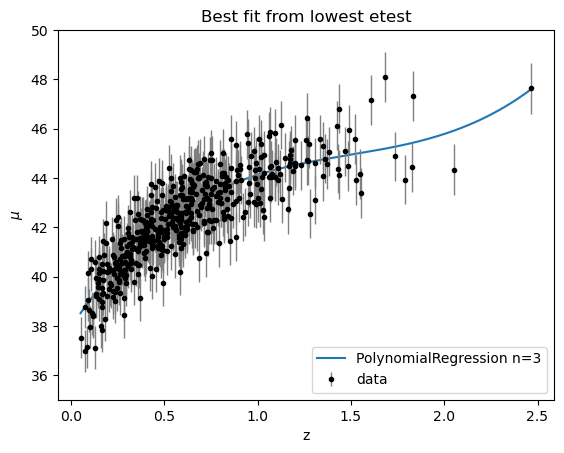

In [128]:
degree = nrange[np.argmin(etest)]
model = PolynomialRegression(degree) # fit 3rd degree polynomial
model.fit(X, y,y_error=dmu)

y_pred = model.predict(X)
n_constraints = degree + 1

print(model.coef_)

X_test = np.linspace(min(z_sample),max(z_sample),1000)[:, np.newaxis]
y_pred = model.predict(X_test)

plt.plot(X_test[:,0],y_pred,label='PolynomialRegression n='+str(degree))
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.title('Best fit from lowest etest')
plt.ylim(35,50);

In [129]:
# CROSS VALIDATION

In [130]:
degrees = np.arange(1,20)

In [131]:
cv_scores = []

for i in range(len(degrees)):
    polynomial_features = PolynomialFeatures(degree=degrees[i], include_bias=False)
    linear_regression = LinearRegression()
    pipeline = Pipeline(
        [
            ("polynomial_features", polynomial_features),
            ("linear_regression", linear_regression),
        ]
    )
    pipeline.fit(X, y)

    # Evaluate the models using crossvalidation
    scores = cross_val_score(
        pipeline, X, y, scoring='explained_variance',cv=5
    )
    cv_scores.append(scores.mean())
    

In [132]:
best_ind_cv = degrees[np.argmax(cv_scores)]

[37.9303641  11.53882123 -6.88381329  1.53889894]


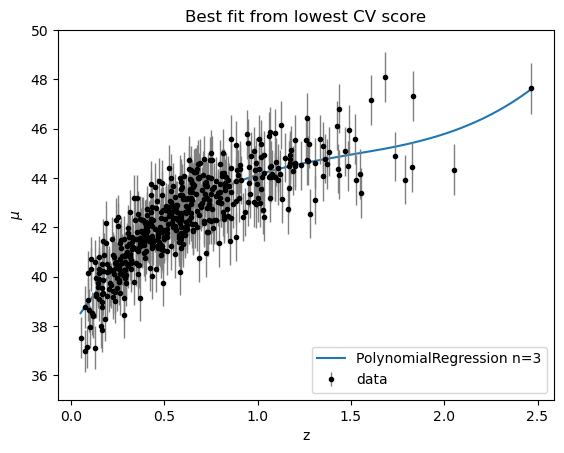

In [133]:
degree = best_ind_cv
model = PolynomialRegression(degree) # fit 3rd degree polynomial
model.fit(X, y,y_error=dmu)

y_pred = model.predict(X)
n_constraints = degree + 1

print(model.coef_)

X_test = np.linspace(min(z_sample),max(z_sample),1000)[:, np.newaxis]
y_pred = model.predict(X_test)

plt.plot(X_test[:,0],y_pred,label='PolynomialRegression n='+str(degree))
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.title('Best fit from lowest CV score')
plt.ylim(35,50);